# Job training and subsequent earnings: data preprocessing

This notebook loads the raw National JTPA Study extract, checks it, recodes the imputed baseline characteristics, and saves the processed data used by the analysis notebooks ([IV regression](02_iv_regression.ipynb) and [matching](03_matching.ipynb)).

- **Outcome `Y`:** total earnings in the 30 months following random assignment.
- **Assignment `Z`:** randomized offer of JTPA services.
- **Treatment `T`:** actual enrollment in JTPA services.

## 1. Data and preprocessing

In [1]:
from pathlib import Path
from importlib.metadata import version
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 110})
pd.set_option("display.max_columns", 25)

In [2]:
# Locate the project from either its root or the notebooks directory.
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "data/raw/jtpa.raw").is_file()
        and (path / "docs/data_dictionary.csv").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside job-training-causal-inference.")
RAW_DATA = PROJECT_ROOT / "data/raw/jtpa.raw"
FIGURES_DIR = PROJECT_ROOT / "outputs/figures"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
for directory in (FIGURES_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)
Y, T, Z = "earnings_30mo", "enrolled", "offer"
print(f"Project: {PROJECT_ROOT}\nPython: {sys.version.split()[0]}")
print(
    " | ".join(
        f"{name} {version(name)}"
        for name in [
            "numpy",
            "pandas",
            "matplotlib",
            "seaborn",
        ]
    )
)

Project: /Users/drewmathieson/Projects/job-training-causal-inference
Python: 3.14.3
numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1 | seaborn 0.13.2


### Source and data checks

Source: [MIT's Angrist Data Archive](https://economics.mit.edu/people/faculty/josh-angrist/angrist-data-archive).

In [3]:
dictionary = pd.read_csv(PROJECT_ROOT / "docs/data_dictionary.csv")
columns = dictionary.sort_values("source_column")["name"].tolist()
raw = pd.read_csv(RAW_DATA, sep=r"\s+", header=None, names=columns)
assert raw.shape == (11_204, len(columns)), "Unexpected source shape."
assert raw["person_id"].is_unique, "Expected one row per person."
assert raw[[Z, T, "male"]].isin([0, 1]).all().all()
assert raw[Y].ge(0).all()
df = raw.copy()
print(f"Loaded {len(raw):,} people and {raw.shape[1]} source columns.")
display(raw.head())

Loaded 11,204 people and 19 source columns.


,person_id,earnings_30mo,offer,enrolled,male,hsorged,black,hispanic,married,wkless13,afdc,age2225,age2629,age3035,age3644,age4554,class_tr,ojt_jsa,f2sms
0,300001,1353,1,1,0,1.0,1,0,0.000000,1.0,0,0,0,0,0,1,0,0,0
1,300002,4984,1,1,0,1.0,0,0,0.000000,0.0,0,1,0,0,0,0,0,0,0
2,300006,27707,1,0,0,1.0,0,1,1.000000,1.0,0,0,0,1,0,0,1,0,0
3,300008,31860,1,0,0,1.0,0,0,0.000000,0.0,0,0,0,1,0,0,0,1,0
4,300010,26615,0,0,0,0.0,0,0,0.211161,0.0,0,1,0,0,0,0,0,1,0


In [4]:
display(dictionary)
display(
    pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing": df.isna().sum(),
            "unique_values": df.nunique(),
        }
    )
)

,source_column,name,description,role
0,1,person_id,Record identifier; not a covariate.,identifier
1,2,earnings_30mo,Total earnings in dollars over 30 months follo...,outcome
2,3,offer,Random assignment to an offer of JTPA services...,instrument / assignment
3,4,enrolled,Actual enrollment in JTPA services: 1 enrolled...,treatment
4,5,male,"Source sex coding: 1 male, 0 female.",baseline characteristic
5,6,hsorged,High-school diploma or GED indicator; fraction...,baseline characteristic
6,7,black,Source indicator for Black participants.,baseline characteristic
7,8,hispanic,Source indicator for Hispanic participants.,baseline characteristic
8,9,married,Marital-status indicator; fractional entries o...,baseline characteristic
9,10,wkless13,Prior-employment variable. Verify the threshol...,baseline characteristic; review coding


,dtype,missing,unique_values
person_id,int64,0,11204
earnings_30mo,int64,0,8321
offer,int64,0,2
enrolled,int64,0,2
male,int64,0,2
hsorged,float64,0,4
black,int64,0,2
hispanic,int64,0,2
married,float64,0,4
wkless13,float64,0,4


### Research why married, hsorged, and wkless13 have 4 values

By reading the associated paper, we discover that the data currently treats missing values for these three features by imputing a sex-specific fractional value.  Marital status, for example, is using the proportion of people within that category that are married, split by men vs women.  Since missing marital status, prior education or prior employment may not be independent across our sample, I will instead add an unknown category so we don't unintentionally bias our data. This gives the missing group its own intercept, independent of the yes/no groups. Ultimately, either decision likely will not affect our model or standard errors much, but in my opinion treating missing data as unknown is more honest and interpretable. I do not recommend simply dropping the population with missing values as it will decrease our statistical strength of our analysis, and I do not know if missingness is independent of our outcome, which means dropping could lead to bias.

Note that treating missing as unknown is not without its own potential to increase bias: [Missing-indicator methods and their limitations](https://pmc.ncbi.nlm.nih.gov/articles/PMC3414599/).  However, in this instance, data was collected before random assignment, so missingness is independent of exposure.  

#### Reclassify missing values as missing.

The preprocessing below applies the Unknown-category rule to marriage status (married), prior employment (wkless13), and prior education (hsorged).

In [5]:
def binary_with_unknown(series, labels):
    """Keep source 0/1; represent fractional or missing entries as Unknown."""
    unknown = series.isna() | (series.gt(0) & series.lt(1))
    if not (series.isin([0, 1]) | unknown).all():
        raise ValueError(f"Unexpected codes in {series.name}; inspect before recoding.")
    values = series.map({0: labels[0], 1: labels[1]}).fillna("Unknown")
    return pd.Categorical(values, categories=[*labels, "Unknown"])


# Start from raw so this cell is safe to rerun. No redundant unknown indicators.
df = raw.copy()
status_specs = {
    "married": ("married", ["Not married", "Married"]),
    "hsorged": ("hsorged", ["No diploma/GED", "Diploma/GED"]),
    "prior_employment_status": (
        "wkless13",
        [
            "Worked 13 weeks or more in prior year",
            "Worked less than 13 weeks in prior year",
        ],
    ),
}
for target, (source, labels) in status_specs.items():
    df[target] = binary_with_unknown(raw[source], labels)

unknown_status_summary = pd.DataFrame(
    [
        {
            "Variable": name,
            "Unknown": int(df[name].eq("Unknown").sum()),
            "Unknown share": df[name].eq("Unknown").mean(),
        }
        for name in status_specs
    ]
)
display(
    unknown_status_summary.style.hide(axis="index").format(
        {"Unknown": "{:,.0f}", "Unknown share": "{:.2%}"}
    )
)

Variable,Unknown,Unknown share
married,764,6.82%
hsorged,695,6.20%
prior_employment_status,"1,178",10.51%


## 2. Earnings distribution

I'll now inspect the earnings distribution using both linear and log scales.  Notice the sizable portion of 0 earners.

Zero earnings: 1,332 of 11,204 people (11.9%)


,30-month earnings ($)
count,11204.00
mean,15815.29
std,16767.05
min,0.00
25%,1929.75
50%,11010.00
75%,24798.25
max,155760.00


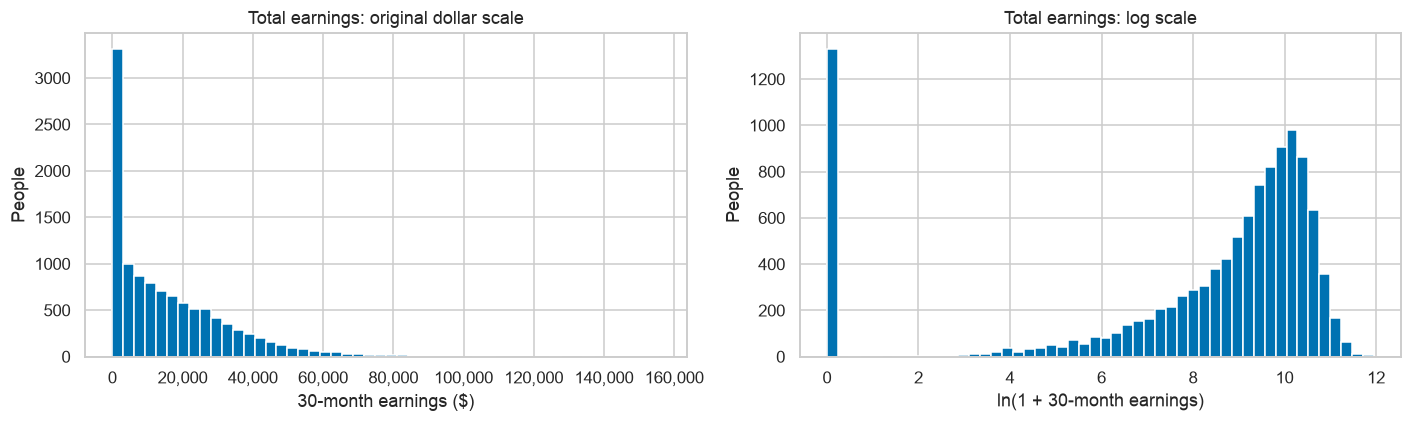

In [6]:
print(
    f"Zero earnings: {df[Y].eq(0).sum():,} of {len(df):,} people ({df[Y].eq(0).mean():.1%})"
)
display(df[Y].describe().to_frame("30-month earnings ($)").round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[Y], bins=50, color="#0072B2")
axes[0].set(
    title="Total earnings: original dollar scale",
    xlabel="30-month earnings ($)",
    ylabel="People",
)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[1].hist(np.log1p(df[Y]), bins=50, color="#0072B2")
axes[1].set(
    title="Total earnings: log scale",
    xlabel="ln(1 + 30-month earnings)",
    ylabel="People",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "earnings_distribution.png", bbox_inches="tight")
plt.show()
# Both plots include zero earners; all regression outcomes remain in dollars.

Our distribution is right-skewed due to a very large number of 0 earners.  This poses significant downside for using a log transformation. We have to either drop the 0 earners, which make up a huge portion of our sample and are essential to answering the causal question. Or we have to transform the log by adding some constant C.  This arbitrary choice of C will cause our estimate to depend on C and be less interpretable, and we additionally lose the property of the log-estimate being a percentage increase in wages.

For these reasons, we continue by using the dollar-scale earnings, which leads to an interpretable estimate and cleaner handling of 0 earners.  The usual argument against dollar-scale is large outlier effects due to skewed distributions, but our large sample size and use of robust standard errors will mitigate those issues.  

## 3. Save the processed data

The analysis notebooks load this file instead of repeating the preprocessing. The recoded `prior_employment_status` takes the place of the source `wkless13` column.

In [7]:
processed = df[
    ["prior_employment_status" if name == "wkless13" else name for name in columns]
]
assert processed.notna().all().all(), "Processed data should have no missing values."
processed.to_csv(PROCESSED_DIR / "jtpa_preprocessed.csv", index=False)
print(f"Saved {len(processed):,} people and {processed.shape[1]} columns.")
display(processed.head())

Saved 11,204 people and 19 columns.


,person_id,earnings_30mo,offer,enrolled,male,hsorged,black,hispanic,married,prior_employment_status,afdc,age2225,age2629,age3035,age3644,age4554,class_tr,ojt_jsa,f2sms
0,300001,1353,1,1,0,Diploma/GED,1,0,Not married,Worked less than 13 weeks in prior year,0,0,0,0,0,1,0,0,0
1,300002,4984,1,1,0,Diploma/GED,0,0,Not married,Worked 13 weeks or more in prior year,0,1,0,0,0,0,0,0,0
2,300006,27707,1,0,0,Diploma/GED,0,1,Married,Worked less than 13 weeks in prior year,0,0,0,1,0,0,1,0,0
3,300008,31860,1,0,0,Diploma/GED,0,0,Not married,Worked 13 weeks or more in prior year,0,0,0,1,0,0,0,1,0
4,300010,26615,0,0,0,No diploma/GED,0,0,Unknown,Worked 13 weeks or more in prior year,0,1,0,0,0,0,0,1,0
